Look at speed distributon for explore vs homing/escape! What happens when doing residual and a higher bin is not present?!?!

In [1]:
from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

experiments_objects = {"JAL4_3rdSept": JAL4_3rdSept,
        "JAL4_19thSept": JAL4_19thSept,
        "JAL4_28aug": JAL4_28aug,
        "JAL4_11thSept": JAL4_11thSept,
        "JAL5_8thSept": JAL005_8thSept,
        "JAL5_21stSept": JAL005_21stSept,
        "JAL6_28mar": JAL6_28mar, 
        "JAL6_flip4_21mar": JAL6_flip4_21mar, 
        "JAL6_flip3_18mar": JAL6_flip3_18mar, 
        "JAL6_flip5_25mar": JAL6_flip5_25mar, 
        "JAL7_sesh8_9apr": JAL7_sesh8_9apr, # almost no homings
        "JAL7_flip5_22mar": JAL7_flip5_22mar, 
        "JAL7_flip2_12mar": JAL7_flip2_12mar, 
        "JAL7_sesh9_16apr": JAL7_sesh9_16apr, 
        "JAL7_23apr": JAL7_23apr,
        "JAL8_flip1_25apr": JAL8_flip1_25apr, 
        "JAL8_flip2_29apr": JAL8_flip2_29apr, 
        "JAL8_flip3_7may": JAL8_flip3_7may, 
        "JAL8_14may": JAL8_14may, 
        "JAL8_flip4_10may": JAL8_flip4_10may}

In [3]:
%load_ext autoreload
%autoreload 2

from behave_analysis.process.process import Process
from settings.settings_analyze_behave import settings_analyze_behave as settings
from behave_analysis.visualize.visualize_utils import open_tracking_data
from behave_analysis.analyze.EscapePattern.escape_pattern_utils import compute_dist_shelt
from behave_analysis.analyze.behaviour.spatial_efficiency import plot_optimal_trajectories
from behave_analysis.utils.arena_plotting import Arena
from behave_analysis.analyze.filtering_data.filtering_functions import filter_video_dataframe

import os
import numpy as np
import dill as pickle
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import polars as pl
%matplotlib inline
cond_list = ["shelter_only", "barrier_pre_flip", "barrier_post_flip"]
bins = np.arange(0,151,5)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
e = 19

session_name = list(experiments_objects.keys())[e]
exp = experiments_objects[session_name]
session = Process(exp).load_session()
video_df = pl.read_csv(os.path.join(session.base_path, session.processed_path) + "\\" + "full_video_dataframe.csv")

2026-03-24 12:49:12.211 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now


2026-03-24 15:02:36.274 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-03-24 15:02:57.475 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-03-24 15:03:18.777 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now


No homing period column for JAL4_19thSept, skipping...


2026-03-24 15:03:38.281 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-03-24 15:04:07.484 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-03-24 15:04:32.799 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-03-24 15:05:00.026 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-03-24 15:05:25.573 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-03-24 15:05:49.241 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now


No homing period column for JAL6_flip4_21mar, skipping...


2026-03-24 15:06:13.266 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-03-24 15:06:37.196 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now


No homing period column for JAL6_flip5_25mar, skipping...


2026-03-24 15:07:03.824 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-03-24 15:07:33.011 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-03-24 15:07:57.849 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now


No homing period column for JAL7_sesh9_16apr, skipping...


2026-03-24 15:08:23.653 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-03-24 15:08:49.998 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-03-24 15:09:15.590 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-03-24 15:09:39.747 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-03-24 15:10:06.594 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-03-24 15:10:32.923 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now


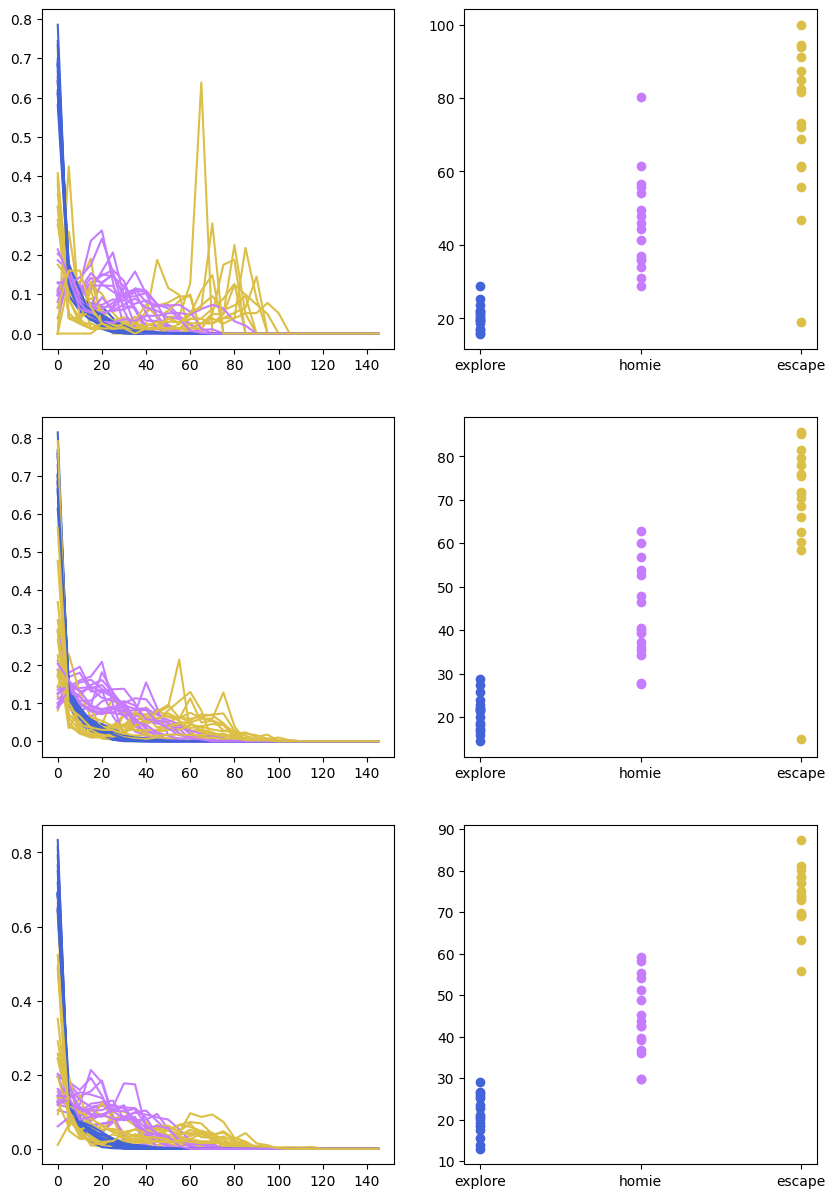

In [16]:
explore_speed = np.full((len(experiments_objects),len(cond_list),len(bins)-1), np.nan)
homie_speed = np.full((len(experiments_objects),len(cond_list),len(bins)-1), np.nan)
escape_speed = np.full((len(experiments_objects),len(cond_list),len(bins)-1), np.nan)
explore_95perc_speed = np.full((len(experiments_objects),len(cond_list)), np.nan)
homie_95perc_speed = np.full((len(experiments_objects),len(cond_list)), np.nan)
escape_95perc_speed = np.full((len(experiments_objects),len(cond_list)), np.nan)

fig, axs = plt.subplots(3,2, figsize=(10,15))

for e, exp in enumerate(experiments_objects.values()):
    session = Process(exp).load_session()
    video_df = pl.read_csv(os.path.join(session.base_path, session.processed_path) + "\\" + "full_video_dataframe.csv")
    session_name = list(experiments_objects.keys())[e]
    if "homingPeriod" not in video_df.columns:
        print(f"No homing period column for {session_name}, skipping...")
        continue
    for c in cond_list:
        # explore!
        filt_vid_df_explore = filter_video_dataframe(video_df, condition = c, outofshelter=True, exclude_escape=True,
                                                        exclude_homings=True)
        hist, _ = np.histogram(filt_vid_df_explore['speed'].to_numpy(), bins)
        explore_speed[e, cond_list.index(c), :] = hist/len(filt_vid_df_explore)
        explore_95perc_speed[e, cond_list.index(c)] = np.percentile(filt_vid_df_explore['speed'].to_numpy(), 95)
        axs[cond_list.index(c),0].plot(bins[:-1], explore_speed[e, cond_list.index(c), :], label="explore" if e == 0 else None, c = "#4363d8")
        axs[cond_list.index(c),1].scatter(0,explore_95perc_speed[e, cond_list.index(c)],c="#4363d8")
        # homie
        filt_vid_df_explore = filter_video_dataframe(video_df, condition = c, outofshelter=True, exclude_escape=True,
                                                        select_homings=True)
        hist, _ = np.histogram(filt_vid_df_explore['speed'].to_numpy(), bins)
        homie_speed[e, cond_list.index(c), :] = hist/len(filt_vid_df_explore)
        homie_95perc_speed[e, cond_list.index(c)] = np.percentile(filt_vid_df_explore['speed'].to_numpy(), 95)
        axs[cond_list.index(c),0].plot(bins[:-1], homie_speed[e, cond_list.index(c), :], c = "#C77CFF", label = "homie" if e == 0 else None)
        axs[cond_list.index(c),1].scatter(1,homie_95perc_speed[e, cond_list.index(c)],c="#C77CFF")
        # escape
        filt_vid_df_explore = filter_video_dataframe(video_df, condition = c, outofshelter=True, exclude_escape=False, select_escape = True)
        if len(filt_vid_df_explore) > 0:
            hist, _ = np.histogram(filt_vid_df_explore['speed'].to_numpy(), bins)
            escape_speed[e, cond_list.index(c), :] = hist/len(filt_vid_df_explore)
            escape_95perc_speed[e, cond_list.index(c)] = np.percentile(filt_vid_df_explore['speed'].to_numpy(), 95)
            axs[cond_list.index(c),0].plot(bins[:-1], escape_speed[e, cond_list.index(c), :], c = "#dcbf46", label = "escape" if e == 0 else None)
            axs[cond_list.index(c),1].scatter(2,escape_95perc_speed[e, cond_list.index(c)],c="#dcbf46")

        axs[cond_list.index(c),1].set_xticks([0,1,2])
        axs[cond_list.index(c),1].set_xticklabels(["explore", "homie", "escape"])

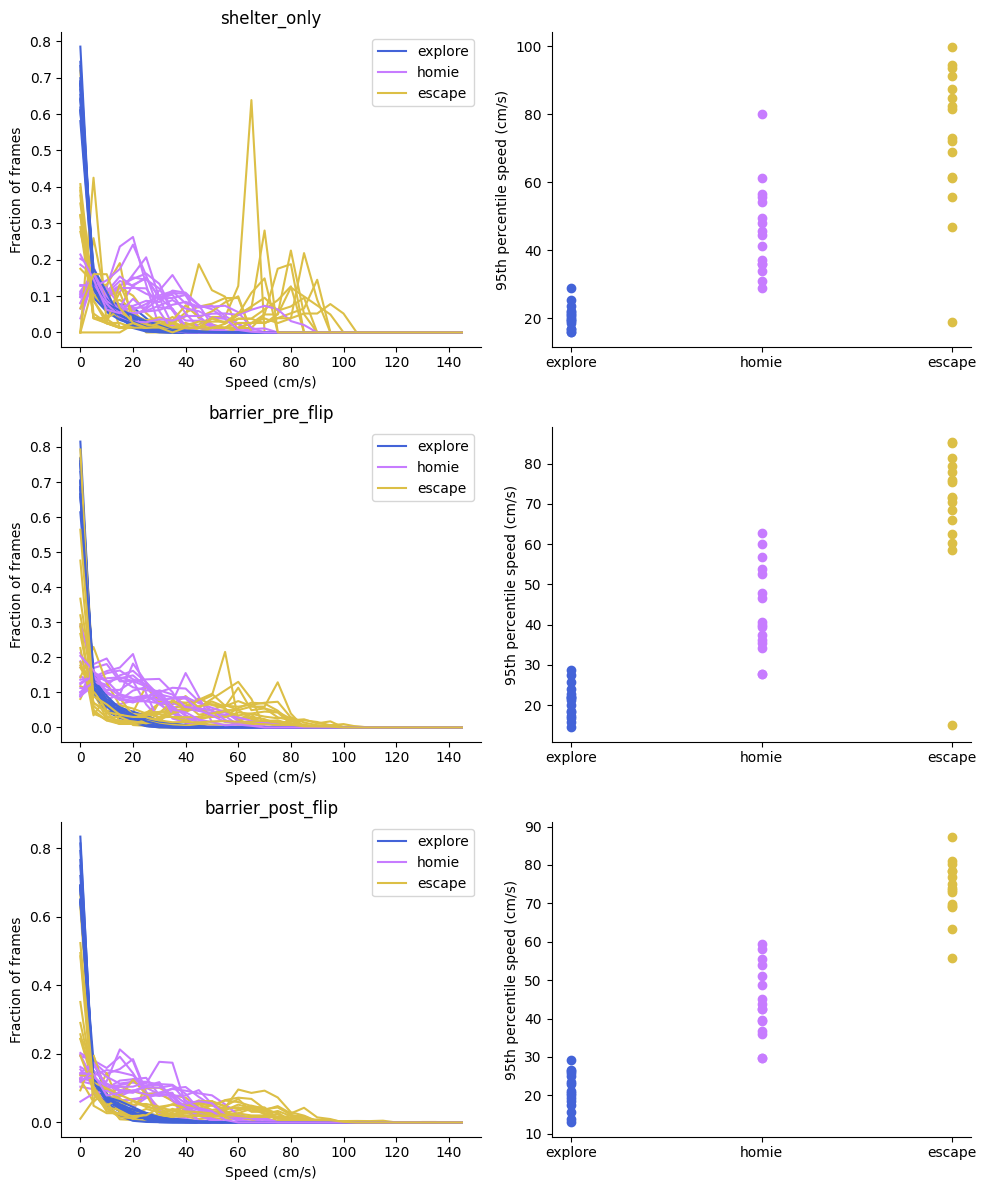

In [17]:
fig, axs = plt.subplots(3,2, figsize=(10,12))

for e in range(len(experiments_objects.values())):
    for c in cond_list:
        axs[cond_list.index(c),0].plot(bins[:-1], explore_speed[e, cond_list.index(c), :], label="explore" if e == 0 else None, c = "#4363d8")
        axs[cond_list.index(c),1].scatter(0,explore_95perc_speed[e, cond_list.index(c)],c="#4363d8")
        # homie
        axs[cond_list.index(c),0].plot(bins[:-1], homie_speed[e, cond_list.index(c), :], c = "#C77CFF", label = "homie" if e == 0 else None)
        axs[cond_list.index(c),1].scatter(1,homie_95perc_speed[e, cond_list.index(c)],c="#C77CFF")
        # escape
        axs[cond_list.index(c),0].plot(bins[:-1], escape_speed[e, cond_list.index(c), :], c = "#dcbf46", label = "escape" if e == 0 else None)
        axs[cond_list.index(c),1].scatter(2,escape_95perc_speed[e, cond_list.index(c)],c="#dcbf46")

        axs[cond_list.index(c),1].set_xticks([0,1,2])
        axs[cond_list.index(c),1].set_xticklabels(["explore", "homie", "escape"])

        if e == 0:
            axs[cond_list.index(c),0].legend()
            axs[cond_list.index(c),0].set_title(c)
            axs[cond_list.index(c),0].set_ylabel("Fraction of frames")
            axs[cond_list.index(c),0].set_xlabel("Speed (cm/s)")
            axs[cond_list.index(c),0].spines["top"].set_visible(False)
            axs[cond_list.index(c),0].spines["right"].set_visible(False)
            axs[cond_list.index(c),1].set_ylabel("95th percentile speed (cm/s)")
            axs[cond_list.index(c),1].spines["top"].set_visible(False)
            axs[cond_list.index(c),1].spines["right"].set_visible(False)

plt.tight_layout()